In [1]:
#%pip install librosa music21 numpy matplotlib soundfile
#%pip install pandas

In [2]:
import os
import librosa
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


df = pd.read_csv("key_acoustic.csv")

input_folder = "input"


x = []
y = []

def extract_features(file_path):
    y_audio, sr = librosa.load(file_path, sr=16000)

    mfcc = np.mean(librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=y_audio, sr=sr).T, axis=0)
    centroid = np.mean(librosa.feature.spectral_centroid(y=y_audio, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y_audio))

    return np.hstack((mfcc, chroma, centroid, zcr))

for _, row in df.iterrows():
    
    sample = row["sample"] + ".wav"
    true_pitch = row["true_pitch"]

    file_path = os.path.join(input_folder, sample)

    if os.path.exists(file_path):

        y_audio, sr = librosa.load(file_path, sr=16000)

        # feature extraction
        feature = extract_features(file_path)
        x.append(feature)
        y.append(true_pitch)

x = np.array(x)
y = np.array(y)

# -----------------------------
# split
# -----------------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)



/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    min_samples_split=2,
    min_samples_leaf=1
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.2%}")

Accuracy: 99.19%


In [4]:
'''from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_acc:.2%}")'''

'from sklearn.svm import SVC\nfrom sklearn.metrics import accuracy_score\n\nsvm_model = SVC()\n\nsvm_model.fit(X_train, y_train)\n\ny_pred_svm = svm_model.predict(X_test)\n\nsvm_acc = accuracy_score(y_test, y_pred_svm)\n\nprint(f"SVM Accuracy: {svm_acc:.2%}")'

In [5]:
'''from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_acc:.2%}")'''

'from sklearn.neighbors import KNeighborsClassifier\n\nknn_model = KNeighborsClassifier(n_neighbors=3)\n\nknn_model.fit(X_train, y_train)\n\ny_pred_knn = knn_model.predict(X_test)\n\nknn_acc = accuracy_score(y_test, y_pred_knn)\n\nprint(f"KNN Accuracy: {knn_acc:.2%}")'

In [4]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)

mlp_model.fit(x_train, y_train)

y_pred_mlp = mlp_model.predict(x_test)

mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"MLP Accuracy: {mlp_acc:.2%}")

/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


MLP Accuracy: 78.46%


/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# scale
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# train
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)

mlp_model.fit(x_train_scaled, y_train)

# predict
y_pred_mlp = mlp_model.predict(x_test_scaled)

# accuracy
s_mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"Scaled MLP Accuracy: {s_mlp_acc:.2%}")

/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Scaled MLP Accuracy: 99.59%


/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amishasingh/Documents/sheetgenie/nsynth/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [6]:
print(
    f"RandomForestClassifier: {acc:.2%}\n"
    #f"SVM: {svm_acc:.2%}\n"
    #f"KNN: {knn_acc:.2%}\n"
    f"MLP: {mlp_acc:.2%}\n"
    f"scaled MLP: {s_mlp_acc:.2%}\n"
)

RandomForestClassifier: 99.19%
MLP: 78.46%
scaled MLP: 99.59%



In [7]:
df["true_pitch"].value_counts()

true_pitch
53    96
51    96
55    96
54    96
48    96
50    96
52    96
56    96
49    96
46    91
45    91
47    91
44    91
Name: count, dtype: int64

In [10]:
#%pip install scikit-learn

<Axes: >

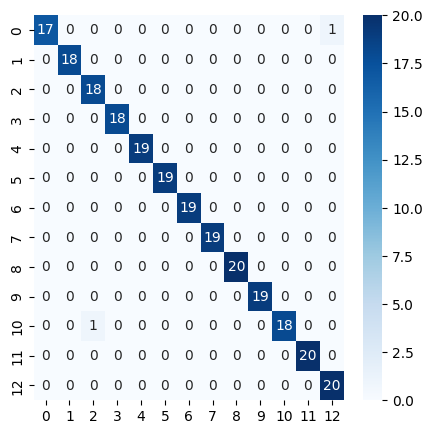

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")


In [9]:
import joblib
joblib.dump(model,"rf_13_classifier.pkl")

['rf_13_classifier.pkl']

In [19]:
predicted_notes=[]
def predict_note(file_path):
    feature=extract_features(file_path)
    feature=feature.reshape(1,-1)

    pred_pitch=model.predict(feature)[0]
    pred_note=librosa.midi_to_note(pred_pitch)
    if "♯" in pred_note:
        pred_note=pred_note.replace("♯", "#")
    
    elif "♭" in pred_note:
        pred_note=pred_note.replace("♭", "b")
    predicted_notes.append(pred_note)
    
    return pred_pitch, pred_note

In [21]:
from music21 import stream, note

In [25]:
def create_seq_sheet(predicted_notes):
    s=stream.Stream()
    for i in predicted_notes:
        n=note.Note(i)
        n.quarterLength=1
        s.append(n)

    s.write("musicxml", "./output/seq_sheet.xml")
    print("Sheet music created at ./output/seq_sheet.xml")

In [26]:
model = joblib.load("rf_13_classifier.pkl")

inference_samples=[
    "keyboard_acoustic_018-045-127",
    "keyboard_acoustic_000-047-127",
    "keyboard_acoustic_007-049-075",
    "keyboard_acoustic_011-053-127",

]
import json
with open("nsynth-train/examples.json", "r") as f:
    data=json.load(f)

predicted_notes =[]
for i in inference_samples:
    true_pitch=data[i]["pitch"]
    true_midi=librosa.midi_to_note(true_pitch)

    audiopath=os.path.join("nsynth-train/audio/"+i+".wav")

    feature=extract_features(audiopath)
    pred_pitch, pred_note=predict_note(audiopath)

    print(f"{i}")
    print(f"Predicted midi: {pred_pitch}")
    print(f"True midi: {true_pitch}")
    
    print(f"Predicted note: {pred_note}")
    print(f"True note: {true_midi}")

create_seq_sheet(predicted_notes)



keyboard_acoustic_018-045-127
Predicted midi: 45
True midi: 45
Predicted note: A2
True note: A2
keyboard_acoustic_000-047-127
Predicted midi: 47
True midi: 47
Predicted note: B2
True note: B2
keyboard_acoustic_007-049-075
Predicted midi: 49
True midi: 49
Predicted note: C#3
True note: C♯3
keyboard_acoustic_011-053-127
Predicted midi: 53
True midi: 53
Predicted note: F3
True note: F3
Sheet music created at ./output/seq_sheet.xml
